In [2]:
import torch
import sys
import numpy as np
import os
import yaml
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torchvision
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision import datasets
from data.transforms import get_simclr_data_transforms
from data.multi_view_data_injector import MultiViewDataInjector
import numpy as np
import skimage.transform

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

cwd = os.getcwd()
parent_dir = os.path.dirname(cwd)
print(parent_dir)

Using device: cuda
/home/shirota


In [4]:
work_dir = parent_dir+"/PyTorch-BYOL/runs/Aug02_13-06-23_rock9_dot_atten_test"
config_yml = work_dir+"/checkpoints/config.yaml"
#config_yml = "./configs/config2_simclr_100epoch.yml"
with open(os.path.join(config_yml)) as file:
  config = yaml.load(file, Loader=yaml.SafeLoader)

print(config["network"]["name"])

resnet18


torch.Size([1, 3, 224, 224])


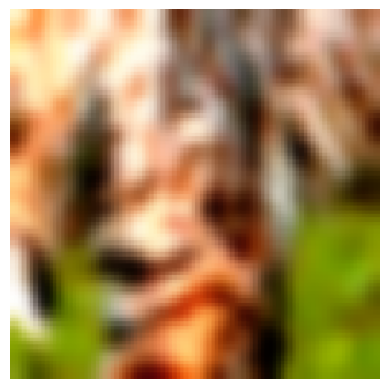

In [25]:
img1 = imgs[0][0].unsqueeze(0)
img1 = F.interpolate(img1, size=(224, 224), mode='nearest')
print(img1.size())
img1 = img1.squeeze(0)
img1 = img1.numpy()
img1 = np.transpose(img1, [1,2,0])
plt.imshow(img1)
plt.axis('off')
plt.show()

In [ ]:
def attention_visualize(img_tensor, alphas,  enc_img_size=14):
    img_tensor = img_tensor.unsqueeze(0)
    img_plt = F.interpolate(img_tensor, size=(224, 224), mode='nearest')
    #print(img_plt.size())
    img_plt = img_plt.squeeze(0)
    img_plt = img_plt.to('cpu').detach().numpy()
    img_plt = np.transpose(img_plt, [1,2,0])
    
    alphas = alphas.view(enc_img_size, enc_img_size)
    alphas = alphas.to('cpu').detach().numpy()
    alphas = skimage.transform.pyramid_expand(
                alphas, upscale=16, sigma=8)#224×#224にする
            
            # タイムステップtの画像をプロット
    plt.imshow(img_plt)
            #plt.text(0, 1, f'{word}', color='black',
            #         backgroundcolor='white', fontsize=12)
    plt.imshow(alphas, alpha=0.65)
    plt.set_cmap(cm.Greys_r)
    plt.axis('off')
    plt.show()
    #plt.savefig(output_save_directory + f'/depth_{atten}_{word}_p{c}.png', bbox_inches='tight')
    plt.clf()

In [5]:
def attention_visualize_imagenet(img_tensor, alphas,  enc_img_size=14):
    #img_tensor = img_tensor.squeeze(0)
    img_np = img_tensor.to('cpu').detach().numpy()
    img_np = np.transpose(img_np, [1,2,0])
    
    alphas = alphas.view(enc_img_size, enc_img_size)
    alphas = alphas.to('cpu').detach().numpy()
    alphas = skimage.transform.pyramid_expand(
                alphas, upscale=16, sigma=8)#224×#224にする
            
        
    plt.imshow(img_np)
            #plt.text(0, 1, f'{word}', color='black',
            #         backgroundcolor='white', fontsize=12)
    plt.imshow(alphas, alpha=0.65, cmap='jet')
    #plt.set_cmap(cm.Greys_r)
    plt.axis('off')
    plt.show()
    #plt.savefig(output_save_directory + f'/depth_{atten}_{word}_p{c}.png', bbox_inches='tight')
    plt.clf()

torch.Size([196])


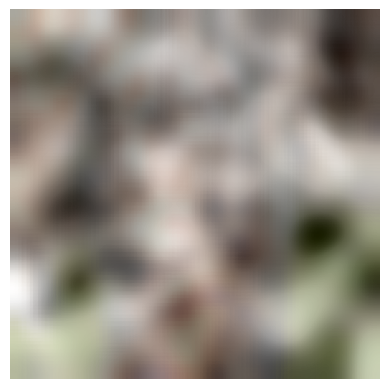

<Figure size 640x480 with 0 Axes>

In [31]:
dummy_aplpha = torch.randn(196)
print(dummy_aplpha.size())
img_tensor = imgs[0][0]
attention_visualize(img_tensor, dummy_aplpha)

In [8]:
from models.resnet_base_network import ResNet_withAttention
from models.attention import NonLinear_Attention, Dot_Attention

In [9]:
online_network = ResNet_withAttention(**config['network']).to(device)
target_network = ResNet_withAttention(**config['network']).to(device)
dim_atten = config['dim_atten']
if config['atten_type'] == 'Non_Linear':
    attention = NonLinear_Attention(online_network.in_features, dim_atten)
elif config['atten_type'] == 'Dot':
    attention = Dot_Attention(online_network.in_features, dim_atten)


state_dict_dir = work_dir+"/checkpoints/model.pth"
load_params = torch.load(os.path.join(state_dict_dir),
                         map_location=torch.device(torch.device(device)))

if 'online_network_state_dict' in load_params:
    online_network.load_state_dict(load_params['online_network_state_dict'])
    print("Parameters successfully loaded (online network).")

if 'target_network_state_dict' in load_params:
    target_network.load_state_dict(load_params['online_network_state_dict'])
    print("Parameters successfully loaded (target network).")

if 'attention_state_dict' in load_params:
    attention.load_state_dict(load_params['attention_state_dict'])
    print("Parameters successfully loaded (attention).")
    
online_network = online_network.to(device)
target_network = target_network.to(device)
attention = attention.to(device)

online_network.eval()
target_network.eval()
attention.eval()

/home/shirota/anaconda3/envs/byol/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shirota/anaconda3/envs/byol/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Parameters successfully loaded (online network).
Parameters successfully loaded (target network).
Parameters successfully loaded (attention).


Dot_Attention(
  (att_for_Keys): Linear(in_features=512, out_features=128, bias=True)
  (att_for_Ques): Linear(in_features=512, out_features=128, bias=True)
)

In [6]:
online_network = ResNet_withAttention(**config['network']).to(device)
target_network = ResNet_withAttention(**config['network']).to(device)
dim_atten = config['dim_atten']
attention = Dot_Attention(online_network.in_features, dim_atten)

online_network = online_network.to(device)
target_network = target_network.to(device)
attention = attention.to(device)

online_network.eval()
target_network.eval()
attention.eval()

/home/shirota/anaconda3/envs/byol/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/shirota/anaconda3/envs/byol/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Dot_Attention(
  (att_for_Keys): Linear(in_features=512, out_features=128, bias=True)
  (att_for_Ques): Linear(in_features=512, out_features=128, bias=True)
)

In [33]:
data_transform = get_simclr_data_transforms(**config['data_transforms'])#224
data_dir = '/home/shirota/ImageNet-100/train'

if config['data']['dataset_name'] == 'stl10':
    dataset = datasets.STL10(data_dir, split='train+unlabeled', download=True,
                             transform=MultiViewDataInjector([data_transform, data_transform]))
        
elif config['data']['dataset_name'] == 'imagenet-100':
    dataset = datasets.ImageFolder(data_dir,
                                   transform=MultiViewDataInjector([data_transform, data_transform]))
    
batch_size = 20
num_workers = 4
dataset_loader = DataLoader(dataset, batch_size=batch_size,
                            num_workers=num_workers, drop_last=False, shuffle=True)

In [34]:
for (batch_view_1, batch_view_2), _ in dataset_loader:
    break

batch_view_1 = batch_view_1.to(device)
batch_view_2 = batch_view_2.to(device)

#print(labels)

In [35]:
with torch.no_grad():
    h1, ext_H1 = online_network(batch_view_1)
    h2, ext_H2 = online_network(batch_view_2)

    # compute key features
    tgt_to_h2, to_ext_H2 = target_network(batch_view_1)
    tgt_to_h1, to_ext_H1 = target_network(batch_view_2)

    cv, alphas_on_view2 = attention(to_ext_H1, ext_H1)
    _, alphas_on_view1 = attention(to_ext_H2, ext_H2)

torch.Size([3, 224, 224])


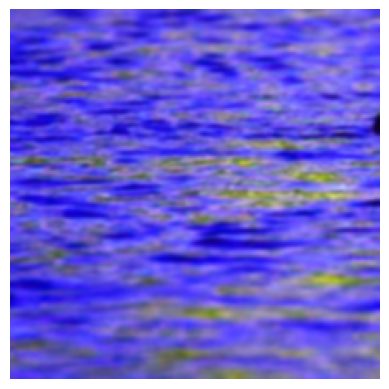

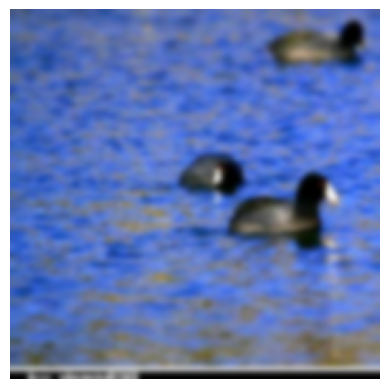

In [57]:
i = 17
view1 = batch_view_1[i]
view2 = batch_view_2[i]
print(view1.size())
plot_view1 = view1.to('cpu').detach().numpy()
plot_view1 = np.transpose(plot_view1, [1,2,0])

plot_view2 = view2.to('cpu').detach().numpy()
plot_view2 = np.transpose(plot_view2, [1,2,0])
plt.figure()
plt.imshow(plot_view1)
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(plot_view2)
plt.axis('off')
plt.show()

In [ ]:
#alphas_on_view2 = torch.rand(20, 196, 196).to(device)

tensor(1., device='cuda:0')


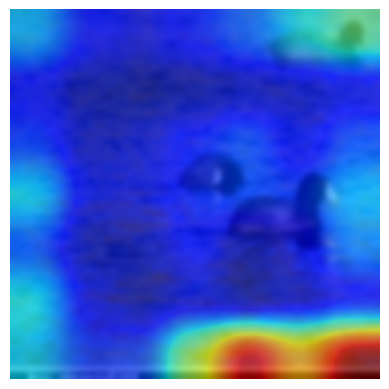

<Figure size 640x480 with 0 Axes>

In [58]:
on_image = batch_view_2[i]
encoded_img_size = config['network']['encoded_img_size'] # 14
x_pos = 6
y_pos = 6
j = x_pos + encoded_img_size*y_pos
alpha = alphas_on_view2[i][j]
print(alpha.sum())
attention_visualize_imagenet(on_image, alpha)

tensor(1.0000, device='cuda:0')


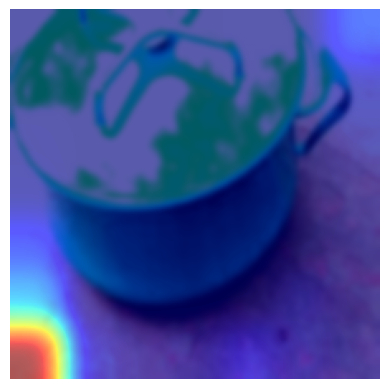

<Figure size 640x480 with 0 Axes>

In [56]:
on_image = batch_view_1[i]
encoded_img_size = config['network']['encoded_img_size'] # 14
x_pos = 0
y_pos = 10
j = x_pos + encoded_img_size*y_pos
alpha = alphas_on_view1[i][j]
print(alpha.sum())
attention_visualize_imagenet(on_image, alpha)

In [14]:
print(cv.size())
ext_H1 = ext_H1.permute(0, 2, 3, 1).flatten(1, 2)
print(ext_H1.size())
cv = cv.reshape(-1, cv.size(-1))
print(cv.size())

torch.Size([3920, 512])
torch.Size([20, 196, 512])
torch.Size([3920, 512])
